In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import boto3
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import catboost
except:
    ! pip install catboost

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-02-18 21:18:40.097569


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/04_parse_payloads_dl/{str_filename}'
df = pd.read_parquet(str_uri)
df['dealerstampcreation__app'] = df['dealerstampcreation__app'].replace('nan', np.nan)
df['dealerstampcreation__app'] = pd.to_datetime(df['dealerstampcreation__app'])
flt_mn = df['dealerstampcreation__app'].mean()
df['dealerstampcreation__app'] = df['dealerstampcreation__app'].fillna(flt_mn)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,monthlyresidual70__bb,monthlyresidual58__bb,monthlyresidual51__bb,monthlyresidual68__bb,monthlyresidual57__bb,monthlyresidual53__bb,monthlyresidual65__bb,monthlyresidual47__bb,monthlyresidual60__bb,monthlyresidual64__bb
0,8425073,2024-11-26 07:01:11+00:00,PRESTIGE-GEN-XII,8425073/6dep-2024-11-26-00:01:11,1,8.425073e+15,8425073.0,10402471.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425080,2024-11-26 07:03:27+00:00,PRESTIGE-GEN-XII,8425080/l72Z-2024-11-26-00:03:27,1,8.425080e+15,8425080.0,10402481.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425104,2024-11-26 07:09:16+00:00,PRESTIGE-GEN-XII,8425104/c979-2024-11-26-00:09:16,1,8.425104e+15,8425104.0,10402507.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425136,2024-11-26 07:18:35+00:00,PRESTIGE-GEN-XII,8425136/6ga3-2024-11-26-00:18:35,1,8.425136e+15,8425136.0,10402546.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,8425173,2024-11-26 07:29:46+00:00,PRESTIGE-GEN-XII,8425173/r5q6-2024-11-26-00:29:46,1,8.425173e+15,8425173.0,10402592.0,1,Texas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,8627588/9pLH-2025-02-06-23:40:52,1,NaN,NaN,NaN,1,Illinois,...,6275.0,6900.0,7800.0,6475.0,7050.0,7625.0,6650.0,8150.0,6650.0,6675.0
0,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,8627590/97E4-2025-02-06-23:41:04,1,NaN,NaN,NaN,1,Louisiana,...,12200.0,13675.0,14825.0,12525.0,13875.0,14625.0,12950.0,15400.0,13375.0,13050.0
0,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,8627613/yyYR-2025-02-06-23:47:03,1,NaN,NaN,NaN,1,Texas,...,11175.0,13300.0,15225.0,11675.0,13575.0,14775.0,12250.0,15975.0,12800.0,12450.0
0,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,8627659/8vmh-2025-02-06-23:57:18,1,NaN,NaN,NaN,1,Georgia,...,10975.0,12950.0,14800.0,11425.0,13250.0,14375.0,11975.0,15525.0,12525.0,12100.0


#### Import preprocessor

In [7]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    str_bucket_path = f'01_ad/02_model/noPTImodel10/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path,
        str_bucket_path=str_bucket_path,
        str_project='20231010-gen-xii',
    )
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

#### Preprocess data

In [8]:
df = cls_model_preprocessing.transform(df)
# rm
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    os.remove(str_filename)
# show
df

NaN Replacer: 0.31224 sec.


100%|██████████| 3/3 [00:00<00:00, 277.26it/s]

Set strings: 0.014794 sec.


Boolean Replacer: 0.50358 sec.


100%|██████████| 1942/1942 [00:01<00:00, 1694.03it/s]


...

Replace inf and -inf with NaN: 1.2165 sec.
Imputer: 0.40103 sec.
Map term: 0.0070878 sec.
Map PTI: 0.005605 sec.


100%|██████████| 7/7 [00:00<00:00, 1832.49it/s]


Round values: 0.012606 sec.
Preprocessing Model: 5.7404 sec.


100%|██████████| 2/2 [00:00<00:00, 3194.44it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,monthlyresidual60__bb,monthlyresidual64__bb,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,8425073,2024-11-26 07:01:11+00:00,PRESTIGE-GEN-XII,8425073/6dep-2024-11-26-00:01:11,1,8.425073e+15,8425073.0,10402471.0,1.0,texas,...,0.0,0.0,2024,0.940900,11,4,0.15,1.239130,3.0,2.20000
0,8425080,2024-11-26 07:03:27+00:00,PRESTIGE-GEN-XII,8425080/l72Z-2024-11-26-00:03:27,1,8.425080e+15,8425080.0,10402481.0,1.0,texas,...,0.0,0.0,2024,0.940900,11,4,0.15,1.250000,5.0,2.20000
0,8425104,2024-11-26 07:09:16+00:00,PRESTIGE-GEN-XII,8425104/c979-2024-11-26-00:09:16,1,8.425104e+15,8425104.0,10402507.0,1.0,texas,...,0.0,0.0,2024,0.940900,11,4,0.15,1.283582,6.0,2.20000
0,8425136,2024-11-26 07:18:35+00:00,PRESTIGE-GEN-XII,8425136/6ga3-2024-11-26-00:18:35,1,8.425136e+15,8425136.0,10402546.0,1.0,texas,...,0.0,0.0,2024,0.940900,11,4,0.15,1.538462,5.0,2.20000
0,8425173,2024-11-26 07:29:46+00:00,PRESTIGE-GEN-XII,8425173/r5q6-2024-11-26-00:29:46,1,8.425173e+15,8425173.0,10402592.0,1.0,texas,...,0.0,0.0,2024,0.940900,11,4,0.15,1.048780,5.0,2.20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,8627588/9pLH-2025-02-06-23:40:52,1,0.000000e+00,0.0,0.0,1.0,illinois,...,6650.0,6675.0,2025,0.912673,2,1,0.15,1.258065,2025.0,2.29863
0,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,8627590/97E4-2025-02-06-23:41:04,1,0.000000e+00,0.0,0.0,1.0,louisiana,...,13375.0,13050.0,2025,0.912673,2,1,0.15,1.212766,2025.0,2.29863
0,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,8627613/yyYR-2025-02-06-23:47:03,1,0.000000e+00,0.0,0.0,1.0,texas,...,12800.0,12450.0,2025,0.912673,2,1,0.15,1.000000,2025.0,2.29863
0,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,8627659/8vmh-2025-02-06-23:57:18,1,0.000000e+00,0.0,0.0,1.0,georgia,...,12525.0,12100.0,2025,0.912673,2,1,0.15,0.966667,2025.0,2.29863


#### PD predictions

In [9]:
str_filename = 'final_model.pkl'
str_model = '02_pricing_pd'
str_bucket_path = f'{str_model}/02_model/noPTImodel10/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20231010-gen-xii',
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['pd'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,monthlyresidual64__bb,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd
0,8425073,2024-11-26 07:01:11+00:00,PRESTIGE-GEN-XII,8425073/6dep-2024-11-26-00:01:11,1,8.425073e+15,8425073.0,10402471.0,1.0,texas,...,0.0,2024,0.940900,11,4,0.15,1.239130,3.0,2.20000,0.338386
0,8425080,2024-11-26 07:03:27+00:00,PRESTIGE-GEN-XII,8425080/l72Z-2024-11-26-00:03:27,1,8.425080e+15,8425080.0,10402481.0,1.0,texas,...,0.0,2024,0.940900,11,4,0.15,1.250000,5.0,2.20000,0.033550
0,8425104,2024-11-26 07:09:16+00:00,PRESTIGE-GEN-XII,8425104/c979-2024-11-26-00:09:16,1,8.425104e+15,8425104.0,10402507.0,1.0,texas,...,0.0,2024,0.940900,11,4,0.15,1.283582,6.0,2.20000,0.126402
0,8425136,2024-11-26 07:18:35+00:00,PRESTIGE-GEN-XII,8425136/6ga3-2024-11-26-00:18:35,1,8.425136e+15,8425136.0,10402546.0,1.0,texas,...,0.0,2024,0.940900,11,4,0.15,1.538462,5.0,2.20000,0.035823
0,8425173,2024-11-26 07:29:46+00:00,PRESTIGE-GEN-XII,8425173/r5q6-2024-11-26-00:29:46,1,8.425173e+15,8425173.0,10402592.0,1.0,texas,...,0.0,2024,0.940900,11,4,0.15,1.048780,5.0,2.20000,0.249676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,8627588/9pLH-2025-02-06-23:40:52,1,0.000000e+00,0.0,0.0,1.0,illinois,...,6675.0,2025,0.912673,2,1,0.15,1.258065,2025.0,2.29863,0.305816
0,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,8627590/97E4-2025-02-06-23:41:04,1,0.000000e+00,0.0,0.0,1.0,louisiana,...,13050.0,2025,0.912673,2,1,0.15,1.212766,2025.0,2.29863,0.303960
0,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,8627613/yyYR-2025-02-06-23:47:03,1,0.000000e+00,0.0,0.0,1.0,texas,...,12450.0,2025,0.912673,2,1,0.15,1.000000,2025.0,2.29863,0.176644
0,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,8627659/8vmh-2025-02-06-23:57:18,1,0.000000e+00,0.0,0.0,1.0,georgia,...,12100.0,2025,0.912673,2,1,0.15,0.966667,2025.0,2.29863,0.306193


#### LGD predictions

In [10]:
str_filename = 'final_model.pkl'
str_model = '03_pricing_lgd'
str_bucket_path = f'{str_model}/02_model/noPTImodel10/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20231010-gen-xii',
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['lgd'] = cls_model_inference.predict(df[list_cols_model])
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd,lgd
0,8425073,2024-11-26 07:01:11+00:00,PRESTIGE-GEN-XII,8425073/6dep-2024-11-26-00:01:11,1,8.425073e+15,8425073.0,10402471.0,1.0,texas,...,2024,0.940900,11,4,0.15,1.239130,3.0,2.20000,0.338386,0.602711
0,8425080,2024-11-26 07:03:27+00:00,PRESTIGE-GEN-XII,8425080/l72Z-2024-11-26-00:03:27,1,8.425080e+15,8425080.0,10402481.0,1.0,texas,...,2024,0.940900,11,4,0.15,1.250000,5.0,2.20000,0.033550,0.646058
0,8425104,2024-11-26 07:09:16+00:00,PRESTIGE-GEN-XII,8425104/c979-2024-11-26-00:09:16,1,8.425104e+15,8425104.0,10402507.0,1.0,texas,...,2024,0.940900,11,4,0.15,1.283582,6.0,2.20000,0.126402,0.618443
0,8425136,2024-11-26 07:18:35+00:00,PRESTIGE-GEN-XII,8425136/6ga3-2024-11-26-00:18:35,1,8.425136e+15,8425136.0,10402546.0,1.0,texas,...,2024,0.940900,11,4,0.15,1.538462,5.0,2.20000,0.035823,0.647023
0,8425173,2024-11-26 07:29:46+00:00,PRESTIGE-GEN-XII,8425173/r5q6-2024-11-26-00:29:46,1,8.425173e+15,8425173.0,10402592.0,1.0,texas,...,2024,0.940900,11,4,0.15,1.048780,5.0,2.20000,0.249676,0.593395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,8627588/9pLH-2025-02-06-23:40:52,1,0.000000e+00,0.0,0.0,1.0,illinois,...,2025,0.912673,2,1,0.15,1.258065,2025.0,2.29863,0.305816,0.729014
0,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,8627590/97E4-2025-02-06-23:41:04,1,0.000000e+00,0.0,0.0,1.0,louisiana,...,2025,0.912673,2,1,0.15,1.212766,2025.0,2.29863,0.303960,0.728410
0,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,8627613/yyYR-2025-02-06-23:47:03,1,0.000000e+00,0.0,0.0,1.0,texas,...,2025,0.912673,2,1,0.15,1.000000,2025.0,2.29863,0.176644,0.654692
0,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,8627659/8vmh-2025-02-06-23:57:18,1,0.000000e+00,0.0,0.0,1.0,georgia,...,2025,0.912673,2,1,0.15,0.966667,2025.0,2.29863,0.306193,0.646098


#### Subset

In [11]:
list_cols = [
    'accountid',
    'request_datetime',
    'response_model_name',
    'bitdebtor',
    'pd',
    'lgd',
]
df = df[list_cols].copy()
# show
df

,accountid,request_datetime,response_model_name,bitdebtor,pd,lgd
0,8425073,2024-11-26 07:01:11+00:00,PRESTIGE-GEN-XII,1,0.338386,0.602711
0,8425080,2024-11-26 07:03:27+00:00,PRESTIGE-GEN-XII,1,0.033550,0.646058
0,8425104,2024-11-26 07:09:16+00:00,PRESTIGE-GEN-XII,1,0.126402,0.618443
0,8425136,2024-11-26 07:18:35+00:00,PRESTIGE-GEN-XII,1,0.035823,0.647023
0,8425173,2024-11-26 07:29:46+00:00,PRESTIGE-GEN-XII,1,0.249676,0.593395
...,...,...,...,...,...,...
0,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,1,0.305816,0.729014
0,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,1,0.303960,0.728410
0,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,1,0.176644,0.654692
0,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,1,0.306193,0.646098


#### Save locally

In [12]:
%%time

str_filename = 'df_predictions.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

CPU times: user 42.5 ms, sys: 7.39 ms, total: 49.9 ms
Wall time: 87.1 ms


#### Group by account

In [13]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'last',
    'response_model_name': 'last',
    'pd': 'mean',
    'lgd': 'mean',
})
# get ecnl
df_tmp['ecnl'] = df_tmp['pd'] * df_tmp['lgd'] * flt_factor_24_to_72 # factor to go from 24 to 72 months loss
# show
df_tmp

,accountid,request_datetime,response_model_name,pd,lgd,ecnl
0,8321703,2024-11-27 21:53:12+00:00,PRESTIGE-GEN-XII,0.115847,0.630854,0.172474
1,8353245,2024-12-04 23:32:24+00:00,PRESTIGE-GEN-XII,0.089682,0.563194,0.119200
2,8375603,2024-12-02 23:02:52+00:00,PRESTIGE-GEN-XII,0.043439,0.591126,0.060600
3,8380765,2024-12-10 04:19:45+00:00,PRESTIGE-GEN-XII,0.131776,0.561194,0.174526
4,8383502,2024-11-27 05:41:46+00:00,PRESTIGE-GEN-XII,0.036059,0.573853,0.048835
...,...,...,...,...,...,...
9995,8627588,2025-02-07 06:40:52+00:00,PRESTIGE-DLV1,0.305816,0.729014,0.526148
9996,8627590,2025-02-07 06:41:04+00:00,PRESTIGE-DLV1,0.303960,0.728410,0.522523
9997,8627613,2025-02-07 06:47:03+00:00,PRESTIGE-DLV1,0.176644,0.654692,0.272928
9998,8627659,2025-02-07 06:57:18+00:00,PRESTIGE-DLV1,0.306193,0.646098,0.466880


#### Save locally

In [14]:
%%time

str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_parquet(str_local_path, compression='gzip')

CPU times: user 45.7 ms, sys: 7.39 ms, total: 53.1 ms
Wall time: 56.6 ms


#### Distribution

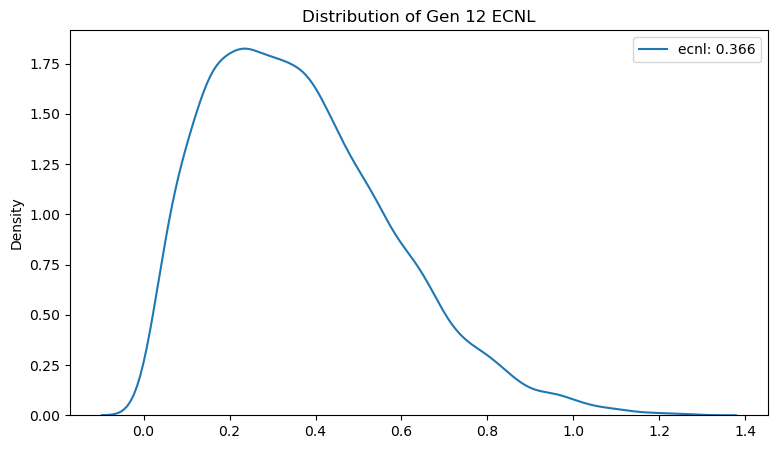

In [15]:
col = 'ecnl'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distribution of Gen 12 ECNL')
flt_mn = df_tmp[col].mean()
str_label = f'{col}: {flt_mn:0.3f}'
sns.kdeplot(list(df_tmp[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()

#### Get quantiles

In [16]:
list_cols = [
    'ecnl',
]
for col in tqdm(list_cols):
    # ml
    arr_score_quantiles = np.percentile(
        list(df_tmp[col]),
        np.linspace(0, 100, 100),
    )
    # save
    str_filename = f'arr_score_quantiles_{col}.pkl'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    pickle.dump(arr_score_quantiles, open(str_local_path, 'wb'))

100%|██████████| 1/1 [00:00<00:00, 305.84it/s]
